# Tokenized Stocks on Solana vs. Nasdaq: Price Behaviour Outside US Market Hours

### Tesla, Nvidia, Alphabet, Apple and Amazon, July 2025 to September 2026

Tokenized stocks trade around the clock on Solana, while the underlying shares trade on Nasdaq only from 9:30 to 16:00 New York time. This project compares five tokenized stocks with their underlying shares and asks what happens to the token price while the stock exchange is closed: overnight, over weekends and over public holidays.

Seven questions are answered:

1. **Price quality:** how close is the token to the stock while both markets are open?
2. **Movement while closed:** how far does the token price move overnight, over weekends and over holidays?
3. **Prediction:** does the token price before the open predict the stock's opening price?
4. **Trading:** does buying the token at the close and selling after the next open make money after costs?
5. **Liquidity:** do thinly traded tokens track the stock worse than heavily traded ones?
6. **Path within a night:** at what time of the night does the token price approach the next opening price?
7. **Before and after hours:** does the token follow the stock's pre-market and post-market price?

Python is used for data collection, cleaning, analysis and charts. Token prices come from a Dune SQL query, stock prices from Yahoo Finance.

| Area | Scope |
|---|---|
| Universe | Five xStocks tokens on Solana (TSLAx, NVDAx, GOOGLx, AAPLx, AMZNx) and their Nasdaq-listed shares |
| Period | 2025-07-08 to 2026-09-30 (450 calendar days, 311 trading days, 310 closed periods) |
| Token data | Dune `dex_solana.trades`, 30-minute volume-weighted prices, trades against USD stablecoins |
| Stock data | Yahoo Finance (`yfinance`), hourly bars including pre-market and post-market |
| Output | Three cleaned tables and one night-level table in `data/clean/`, six charts in `figures/` |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Define Parameters and File Paths

The token data starts on 30 June 2025, the launch day of xStocks on Solana. The analysis window starts on 8 July 2025, because the Amazon token traded at unusable prices during its first week (see Section 9). All timestamps are kept in UTC and converted to New York time only where the stock market calendar is needed, so the two daylight-saving changes in the period are handled automatically.

In [2]:
START = pd.Timestamp("2025-07-08", tz="UTC")           # first half-hour of the analysis window
END = pd.Timestamp("2026-09-30 23:30", tz="UTC")       # last half-hour of the analysis window
NY = "America/New_York"

# Stock prices are downloaded from 1 July so the first night in the window has a previous close
STOCK_DOWNLOAD_START = "2025-07-01"
STOCK_DOWNLOAD_END = "2026-10-01"                      # exclusive, last day is 30 September 2026

RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/clean")
FIG_DIR = Path("figures")
for folder in (RAW_DIR, CLEAN_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

TOKEN_CSV = RAW_DIR / "xstocks_solana_30min_by_quote_2025-06-30_2026-09-30.csv.gz"
OVERVIEW_CSV = RAW_DIR / "xstocks_solana_monthly_overview_fees.csv"
STOCK_CSV = RAW_DIR / "stocks_1h_prepost_2025-07-01_2026-09-30.csv"

# Token symbol -> stock ticker, ordered by stablecoin trading volume, highest first
TICKER = {"TSLAx": "TSLA", "NVDAx": "NVDA", "GOOGLx": "GOOGL", "AAPLx": "AAPL", "AMZNx": "AMZN"}
ORDER = list(TICKER.values())

OUTLIER_LIMIT = 0.05      # token price: max deviation from the rolling median
MEDIAN_WINDOW = 49        # 49 half-hours = about 24 hours, centred
SPIKE_LIMIT = 0.05        # stock bar outside market hours that jumps away and straight back
COSTS = [0.1, 0.3, 0.5, 1.0]   # round-trip trading cost scenarios in percent

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# Chart style: one surface, muted axes, three validated series colours
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": MUTED, "axes.edgecolor": GRID,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
})

## 3. Select the Five Tokens

The five tokens are not picked by hand. They follow from two rules applied to every xStocks token with DEX trades on Solana (monthly overview exported from Dune, query `xstocks_solana_monthly_overview_fees`):

1. **Continuous trading:** at least 5,000 trades in every month from July 2025 to September 2026.
2. **Well-known single company without a crypto link:** ETFs and crypto-related companies are excluded, so readers outside the crypto scene can follow the comparison.

Rule 1 leaves ten tokens. Rule 2 removes the two ETFs (SPYx, QQQx) and the three crypto-related names (CRCLx, MSTRx, HOODx). Excluding HOODx (Robinhood, a broker with a large crypto business) is a judgement call.

In [3]:
MIN_TRADES_PER_MONTH = 5000
EXCLUDED = {"SPYx": "ETF", "QQQx": "ETF", "CRCLx": "crypto-related",
            "MSTRx": "crypto-related", "HOODx": "crypto-related"}

overview = pd.read_csv(OVERVIEW_CSV)
overview["month"] = overview["block_month"].str[:7]
overview = overview[overview["month"] >= "2025-07"]

monthly = overview.groupby(["symbol", "month"]).agg(
    trades=("trades", "sum"), volume_usd=("volume_usd", "sum")).reset_index()
n_months = monthly["month"].nunique()

selection = monthly.groupby("symbol").agg(
    months_above_threshold=("trades", lambda s: int((s >= MIN_TRADES_PER_MONTH).sum())),
    min_trades_in_a_month=("trades", "min"),
    volume_musd=("volume_usd", lambda s: s.sum() / 1e6)).reset_index()
selection = selection[selection["months_above_threshold"] == n_months].copy()
selection["decision"] = selection["symbol"].map(EXCLUDED).fillna("selected")
selection = selection.sort_values("volume_musd", ascending=False).reset_index(drop=True)

print(f"Tokens in the overview: {monthly['symbol'].nunique()} | months: {n_months} | "
      f"tokens with >= {MIN_TRADES_PER_MONTH} trades in every month: {len(selection)}")
selection.round(1)

Tokens in the overview: 145 | months: 15 | tokens with >= 5000 trades in every month: 10


,symbol,months_above_threshold,min_trades_in_a_month,volume_musd,decision
0,SPYx,15,110739,2684.0,ETF
1,CRCLx,15,56522,1187.8,crypto-related
2,NVDAx,15,96190,750.9,selected
3,TSLAx,15,164118,730.5,selected
4,QQQx,15,18174,352.8,ETF
5,MSTRx,15,43736,310.5,crypto-related
6,GOOGLx,15,41533,138.1,selected
7,HOODx,15,6063,90.8,crypto-related
8,AAPLx,15,18036,83.2,selected
9,AMZNx,15,8413,53.1,selected


## 4. Load Token Prices from Dune

Token prices come from the Dune table `dex_solana.trades` (query `xstocks_solana_30min_prices_by_quote`). The query returns one row per token, half-hour and quote type, with the number of trades, the USD volume and the volume-weighted average price (VWAP).

The quote type says what the token was traded against: `stable` (USDC or USDT), `sol` (SOL) or `other` (any other token). Only `stable` trades are used for prices, because a price against a dollar stablecoin needs no second conversion.

In [4]:
tok_raw = pd.read_csv(TOKEN_CSV)
tok_raw["time_utc"] = pd.to_datetime(tok_raw["time_utc"], utc=True)

print("Rows:", len(tok_raw), "| from", tok_raw["time_utc"].min(), "to", tok_raw["time_utc"].max())
tok_raw.groupby("quote_type").agg(rows=("trades", "size"), trades=("trades", "sum"),
                                  volume_musd=("volume_usd", lambda s: s.sum() / 1e6)).round(1)

Rows: 276486 | from 2025-06-30 07:30:00+00:00 to 2026-09-30 23:30:00+00:00


,rows,trades,volume_musd
quote_type,,,
other,73082,3806789,224.2
sol,98406,3131812,179.1
stable,104998,8845687,1354.4


## 5. Download Stock Prices

Hourly bars with pre-market and post-market are downloaded from Yahoo Finance. Shorter intervals were not tested. Hourly bars are enough for the analysis: the first regular bar starts at 9:30, so its open is the official opening price, and the last regular bar ends at 16:00.

Prices are not adjusted for dividends (`auto_adjust=False`), so they match the prices that were actually traded. The download runs only if the file does not exist yet, which keeps the analysis reproducible on a fixed data set.

In [5]:
if not STOCK_CSV.exists():
    frames = []
    for ticker in ORDER:
        d = yf.Ticker(ticker).history(start=STOCK_DOWNLOAD_START, end=STOCK_DOWNLOAD_END,
                                      interval="1h", prepost=True, auto_adjust=False)
        d = d.reset_index().rename(columns={"Datetime": "time_ny"})
        d["time_utc"] = d["time_ny"].dt.tz_convert("UTC")
        d["symbol"] = ticker
        frames.append(d)
    pd.concat(frames, ignore_index=True).to_csv(STOCK_CSV, index=False)

stk_raw = pd.read_csv(STOCK_CSV)
stk_raw["time_utc"] = pd.to_datetime(stk_raw["time_utc"], utc=True)
stk_raw["time_ny"] = stk_raw["time_utc"].dt.tz_convert(NY)

stk_raw.groupby("symbol").agg(rows=("time_utc", "size"), first=("time_ny", "min"),
                              last=("time_ny", "max")).reindex(ORDER)

,rows,first,last
symbol,,,
TSLA,5241,2025-07-01 04:00:00-04:00,2026-09-30 19:00:00-04:00
NVDA,5242,2025-07-01 04:00:00-04:00,2026-09-30 19:00:00-04:00
GOOGL,5240,2025-07-01 04:00:00-04:00,2026-09-30 19:00:00-04:00
AAPL,5241,2025-07-01 04:00:00-04:00,2026-09-30 19:00:00-04:00
AMZN,5240,2025-07-01 04:00:00-04:00,2026-09-30 19:00:00-04:00


## 6. Check Token Data Quality

The check covers duplicates, missing values and invalid prices, and then counts the half-hours without any stablecoin trade. A full grid has 21,600 half-hours per token (450 days times 48).

In [6]:
print("Duplicates:", tok_raw.duplicated(["time_utc", "symbol", "quote_type"]).sum())
print("Missing values:", tok_raw.isna().sum().sum())
print("Price <= 0:", (tok_raw["vwap_usd"] <= 0).sum())

grid = pd.date_range(START, END, freq="30min", name="time_utc")
stable = tok_raw[(tok_raw["quote_type"] == "stable") & (tok_raw["time_utc"] >= START)
                 & (tok_raw["time_utc"] <= END)]

rows = []
for symbol, g in stable.groupby("symbol"):
    have = pd.DatetimeIndex(g["time_utc"])
    is_gap = pd.Series(1, index=have).reindex(grid).isna()
    run_id = (is_gap != is_gap.shift()).cumsum()
    gap_len = is_gap.groupby(run_id).agg(["first", "size"])
    gap_len = gap_len.loc[gap_len["first"], "size"]              # length in half-hours
    rows.append({
        "symbol": symbol, "rows": len(g), "expected": len(grid),
        "missing": int(is_gap.sum()), "missing_pct": round(100 * is_gap.mean(), 1),
        "days_with_data": pd.Series(have.date).nunique(),
        "longest_gap_h": gap_len.max() / 2 if len(gap_len) else 0,
        "gaps_over_2h": int((gap_len > 4).sum()),
    })
pd.DataFrame(rows).set_index("symbol").reindex(TICKER.keys())

Duplicates: 0
Missing values: 0
Price <= 0: 0


,rows,expected,missing,missing_pct,days_with_data,longest_gap_h,gaps_over_2h
symbol,,,,,,,
TSLAx,21599,21600,1,0.0,450,0.5,0
NVDAx,21593,21600,7,0.0,450,0.5,0
GOOGLx,20985,21600,615,2.8,450,6.0,6
AAPLx,20384,21600,1216,5.6,450,4.0,6
AMZNx,18796,21600,2804,13.0,450,5.0,29


The gaps are not spread evenly. The next table shows the share of missing half-hours by market phase: gaps are rare while Nasdaq is open and most frequent at weekends.

In [7]:
def market_phase(index_utc):
    ny = index_utc.tz_convert(NY)
    minute = ny.hour * 60 + ny.minute
    return np.where((ny.dayofweek < 5) & (minute >= 570) & (minute < 960), "market_hours",
           np.where(ny.dayofweek >= 5, "weekend", "overnight"))

expected = pd.Series(market_phase(grid)).value_counts()
gap_share = {}
for symbol, g in stable.groupby("symbol"):
    missing = grid.difference(pd.DatetimeIndex(g["time_utc"]))
    counts = pd.Series(market_phase(missing)).value_counts()
    gap_share[symbol] = (counts.reindex(expected.index, fill_value=0) / expected * 100).round(1)

pd.DataFrame(gap_share).T.reindex(TICKER.keys())[["market_hours", "overnight", "weekend"]]

,market_hours,overnight,weekend
TSLAx,0.0,0.0,0.0
NVDAx,0.0,0.0,0.1
GOOGLx,0.6,2.5,5.0
AAPLx,1.4,5.6,8.6
AMZNx,3.6,13.1,19.2


## 7. Check Stock Data Quality

The same checks for the stock bars, plus the market calendar that follows from the data itself: every weekday without bars is a public holiday, and every trading day without a 15:30 bar is a shortened session. The calendar also gives the number of closed periods by length.

In [8]:
stk_check = stk_raw[stk_raw["time_utc"] >= START].copy()
stk_check["day"] = stk_check["time_ny"].dt.date
stk_check["time"] = stk_check["time_ny"].dt.strftime("%H:%M")

print("Duplicates:", stk_check.duplicated(["symbol", "time_utc"]).sum())
print("Missing values:", stk_check.isna().sum().sum())
print("Price <= 0:", (stk_check[["Open", "High", "Low", "Close"]] <= 0).sum().sum())

trading_days = sorted(stk_check["day"].unique())
weekdays = pd.bdate_range(START.date(), END.date()).date
holidays = [d for d in weekdays if d not in set(trading_days)]
print("Calendar days:", (END.date() - START.date()).days + 1,
      "| weekdays:", len(weekdays), "| trading days:", len(trading_days), "| holidays:", len(holidays))
print("Holidays:", [str(d) for d in holidays])

day_gap = pd.to_datetime(pd.Series(trading_days)).diff().dt.days.dropna().astype(int)
print("Closed periods by length in days (1 = night, 3 = weekend, 2 or 4 = with a holiday):",
      day_gap.value_counts().sort_index().to_dict())

regular_bars = ["09:30", "10:30", "11:30", "12:30", "13:30", "14:30", "15:30"]
rows = []
for symbol, g in stk_check.groupby("symbol"):
    p = g.pivot_table(index="day", columns="time", values="Close", aggfunc="size")
    incomplete = p[regular_bars].isna().any(axis=1)
    rows.append({"symbol": symbol, "rows": len(g), "trading_days": len(p),
                 "days_without_0930_bar": int(p["09:30"].isna().sum()),
                 "shortened_sessions": ", ".join(str(d) for d in p.index[incomplete]),
                 "days_without_1900_bar": int(p["19:00"].isna().sum())})
pd.DataFrame(rows).set_index("symbol").reindex(ORDER)

Duplicates: 0
Missing values: 0
Price <= 0: 0
Calendar days: 450 | weekdays: 322 | trading days: 311 | holidays: 11
Holidays: ['2025-09-01', '2025-11-27', '2025-12-25', '2026-01-01', '2026-01-19', '2026-02-16', '2026-04-03', '2026-05-25', '2026-06-19', '2026-07-03', '2026-09-07']
Closed periods by length in days (1 = night, 3 = weekend, 2 or 4 = with a holiday): {1: 243, 2: 3, 3: 56, 4: 8}


,rows,trading_days,days_without_0930_bar,shortened_sessions,days_without_1900_bar
symbol,,,,,
TSLA,5177,311,0,"2025-11-28, 2025-12-24",86
NVDA,5178,311,0,"2025-11-28, 2025-12-24",86
GOOGL,5176,311,0,"2025-11-28, 2025-12-24",86
AAPL,5177,311,0,"2025-11-28, 2025-12-24",86
AMZN,5176,311,0,"2025-11-28, 2025-12-24",86


Regular sessions are complete for all five stocks. Outside market hours the data is weaker: the 19:00 bar is missing on 86 days, almost all between November 2025 and March 2026, and some bars contain bad prices. The next cell lists every bar-to-bar jump above 8 %. Several of them fall and fully recover within one hour (for example NVDA on 9 July 2025), which marks them as bad ticks rather than real moves. For this reason the official closing price is taken from the last regular bar, not from post-market bars.

In [9]:
stk_check = stk_check.sort_values(["symbol", "time_utc"])
stk_check["jump"] = stk_check.groupby("symbol")["Close"].pct_change().abs()
jumps = stk_check.loc[stk_check["jump"] > 0.08, ["symbol", "time_ny", "Close", "jump"]]
jumps.assign(Close=jumps["Close"].round(2), jump=jumps["jump"].round(3))

,symbol,time_ny,Close,jump
22403,AMZN,2025-10-30 16:00:00-04:00,249.16,0.118
23451,AMZN,2026-02-05 16:00:00-05:00,200.70,0.098
10781,GOOGL,2025-07-25 16:00:00-04:00,174.03,0.099
10782,GOOGL,2025-07-25 17:00:00-04:00,192.94,0.109
11223,GOOGL,2025-09-02 16:00:00-04:00,229.05,0.084
5335,NVDA,2025-07-09 16:00:00-04:00,115.79,0.289
5336,NVDA,2025-07-09 17:00:00-04:00,163.05,0.408
5658,NVDA,2025-08-05 16:00:00-04:00,150.62,0.155
5659,NVDA,2025-08-05 17:00:00-04:00,177.17,0.176
1084,TSLA,2025-10-01 16:00:00-04:00,319.07,0.306


## 8. Clean Stock Data

Each hourly bar is labelled as `pre_market`, `market_hours` or `post_market`. On the shortened trading days the regular session ends at 13:00 instead of 16:00.

A bar outside market hours is flagged as a spike when its close deviates by more than 5 % from both the previous and the next bar in the same direction, i.e. the price jumps away and comes straight back. Real moves after earnings stay on the new level and are not flagged.

In [10]:
stk = stk_raw.rename(columns={"symbol": "ticker", "Open": "open", "High": "high", "Low": "low",
                              "Close": "close", "Volume": "volume", "Dividends": "dividend"})
stk["day"] = stk["time_ny"].dt.date
stk["time"] = stk["time_ny"].dt.strftime("%H:%M")
stk = stk.sort_values(["ticker", "time_utc"]).reset_index(drop=True)

# Shortened trading days have no 15:30 bar; their regular session ends at 13:00
days_with_1530 = set(stk.loc[stk["time"] == "15:30", "day"])
early_close_days = sorted(set(stk["day"]) - days_with_1530)

minute = stk["time_ny"].dt.hour * 60 + stk["time_ny"].dt.minute
close_minute = np.where(stk["day"].isin(early_close_days), 13 * 60, 16 * 60)
stk["session"] = np.where(minute < 570, "pre_market",
                 np.where(minute < close_minute, "market_hours", "post_market"))

dev_prev = stk["close"] / stk.groupby("ticker")["close"].shift(1) - 1
dev_next = stk["close"] / stk.groupby("ticker")["close"].shift(-1) - 1
stk["is_spike"] = ((stk["session"] != "market_hours")
                   & (dev_prev.abs() > SPIKE_LIMIT) & (dev_next.abs() > SPIKE_LIMIT)
                   & (np.sign(dev_prev) == np.sign(dev_next)))

stocks_hourly = stk[["time_utc", "time_ny", "ticker", "session", "open", "high", "low",
                     "close", "volume", "dividend", "is_spike"]]
stocks_hourly.to_csv(CLEAN_DIR / "stocks_1h_clean.csv", index=False)

print("Rows:", len(stocks_hourly), "| spikes flagged:", int(stocks_hourly["is_spike"].sum()))
print("Shortened trading days:", [str(d) for d in early_close_days])

Rows: 26204 | spikes flagged: 11
Shortened trading days: ['2025-07-03', '2025-11-28', '2025-12-24']


The night-level analysis needs one opening and one closing price per stock and trading day. The open is the open of the 9:30 bar, the close is the close of the 15:30 bar. On shortened days Yahoo does not deliver the last half-hour before 13:00, so the open of the 13:00 bar is used as the closing price.

In [11]:
daily = []
for (ticker, day), g in stk.groupby(["ticker", "day"]):
    g = g.set_index("time")
    early = day in early_close_days
    if early:   # 12:30-13:00 is missing in the source; use the open of the 13:00 bar
        close_price, close_time = g.loc["13:00", "open"], "13:00"
    else:
        close_price, close_time = g.loc["15:30", "close"], "16:00"
    daily.append({
        "ticker": ticker, "day": day,
        "open": g.loc["09:30", "open"], "close": close_price,
        "open_utc": pd.Timestamp(f"{day} 09:30", tz=NY).tz_convert("UTC"),
        "close_utc": pd.Timestamp(f"{day} {close_time}", tz=NY).tz_convert("UTC"),
        "early_close": early, "dividend": g["dividend"].sum(),
    })
stocks_daily = pd.DataFrame(daily).sort_values(["ticker", "day"]).reset_index(drop=True)
stocks_daily.to_csv(CLEAN_DIR / "stocks_daily_open_close.csv", index=False)

print("Rows:", len(stocks_daily), "| trading days per stock:", stocks_daily["day"].nunique())
stocks_daily.head()

Rows: 1575 | trading days per stock: 315


,ticker,day,open,close,open_utc,close_utc,early_close,dividend
0,AAPL,2025-07-01,206.664993,207.860001,2025-07-01 13:30:00+00:00,2025-07-01 20:00:00+00:00,False,0.0
1,AAPL,2025-07-02,209.080002,212.410004,2025-07-02 13:30:00+00:00,2025-07-02 20:00:00+00:00,False,0.0
2,AAPL,2025-07-03,212.145004,214.100006,2025-07-03 13:30:00+00:00,2025-07-03 17:00:00+00:00,True,0.0
3,AAPL,2025-07-07,212.679993,209.940002,2025-07-07 13:30:00+00:00,2025-07-07 20:00:00+00:00,False,0.0
4,AAPL,2025-07-08,210.130005,210.035004,2025-07-08 13:30:00+00:00,2025-07-08 20:00:00+00:00,False,0.0


## 9. Clean Token Data

The stablecoin price is placed on a full 30-minute grid, so half-hours without a trade are visible as empty rows instead of being silently absent.

A price is flagged as an outlier when it deviates by more than 5 % from the centred 24-hour rolling median. The centred window follows real price steps (for example after earnings) and only flags prices that stand apart from both sides. Outliers are kept in `vwap_usd` and removed only from `price_usd`, so every flagged value can still be inspected. About half of the outliers carry almost no volume (below 10 USD); a few carry real volume and may be genuine short-lived deviations (for example TSLAx on 15 September 2025).

The Amazon token is the reason for the 8 July start: between 2 and 7 July 2025 it traded between about 180 and 3,300 USD on thin volume (a median of about 265 USD per half-hour), against a real share price of about 225 USD.

In [12]:
parts = []
for symbol, g in stable.groupby("symbol"):
    g = g.set_index("time_utc")[["trades", "volume_usd", "vwap_usd"]].reindex(grid)
    median = g["vwap_usd"].rolling(MEDIAN_WINDOW, center=True, min_periods=5).median()
    g["is_outlier"] = (g["vwap_usd"] / median - 1).abs() > OUTLIER_LIMIT
    g["price_usd"] = g["vwap_usd"].where(~g["is_outlier"])
    g["symbol"], g["ticker"] = symbol, TICKER[symbol]
    parts.append(g.reset_index())
tokens = pd.concat(parts, ignore_index=True)
tokens["trades"] = tokens["trades"].fillna(0).astype(int)
tokens["volume_usd"] = tokens["volume_usd"].fillna(0.0)

tokens.groupby("symbol").agg(
    half_hours=("time_utc", "size"), with_price=("price_usd", "count"),
    outliers=("is_outlier", "sum"),
    no_trade=("vwap_usd", lambda s: int(s.isna().sum()))).reindex(TICKER.keys())

,half_hours,with_price,outliers,no_trade
symbol,,,,
TSLAx,21600,21595,4,1
NVDAx,21600,21589,4,7
GOOGLx,21600,20979,6,615
AAPLx,21600,20379,5,1216
AMZNx,21600,18784,12,2804


## 10. Label Token Half-Hours with the Market Calendar

Every token half-hour gets two labels derived from the stock market calendar of Section 8:

- `session`: `market_hours`, `pre_market` (4:00 to 9:30), `post_market` (close to 20:00) or `closed`.
- `night_type`: for every half-hour outside market hours, the kind of closed period it belongs to: `overnight` (between two consecutive trading days), `weekend`, or `holiday` (the period contains a public holiday).

Each half-hour outside market hours also stores the trading day before and after it. These two dates identify the closed period and are the key for the night table in Section 11.

In [13]:
calendar = stocks_daily[stocks_daily["ticker"] == ORDER[0]].sort_values("day").reset_index(drop=True)
calendar_days = pd.to_datetime(calendar["day"]).to_numpy()
open_ns = calendar["open_utc"].astype("int64").to_numpy()
close_ns = calendar["close_utc"].astype("int64").to_numpy()
t_ns = tokens["time_utc"].astype("int64").to_numpy()

i_open = np.searchsorted(open_ns, t_ns, side="right") - 1      # last open at or before t
in_market = (i_open >= 0) & (t_ns < close_ns[np.clip(i_open, 0, None)])
i_prev = np.searchsorted(close_ns, t_ns, side="right") - 1     # last close at or before t
i_next = i_prev + 1
has_prev = (i_prev >= 0) & ~in_market
has_next = (i_next < len(calendar)) & ~in_market

prev_day = pd.Series(pd.NaT, index=tokens.index, dtype="datetime64[ns]")
next_day = prev_day.copy()
prev_day[has_prev] = calendar_days[i_prev[has_prev]]
next_day[has_next] = calendar_days[i_next[has_next]]

gap_days = (next_day - prev_day).dt.days
closed_weekdays = np.array([                                    # weekdays without trading inside the gap
    np.busday_count(p.date(), n.date()) - 1 if pd.notna(p) and pd.notna(n) else -1
    for p, n in zip(prev_day, next_day)])
tokens["night_type"] = np.where(in_market, "", np.where(gap_days.isna(), "incomplete",
                       np.where(closed_weekdays > 0, "holiday",
                       np.where(gap_days == 1, "overnight", "weekend"))))

time_ny = tokens["time_utc"].dt.tz_convert(NY)
ny_minute = time_ny.dt.hour * 60 + time_ny.dt.minute
trading_today = time_ny.dt.date.isin(set(calendar["day"]))
tokens["session"] = np.where(in_market, "market_hours",
                    np.where(trading_today & (ny_minute >= 240) & (ny_minute < 570), "pre_market",
                    np.where(trading_today & (ny_minute >= 780) & (ny_minute < 1200), "post_market",
                             "closed")))
tokens["prev_trading_day"] = prev_day.dt.date
tokens["next_trading_day"] = next_day.dt.date
tokens["time_ny"] = time_ny

tokens = tokens[["time_utc", "time_ny", "symbol", "ticker", "price_usd", "vwap_usd", "is_outlier",
                 "trades", "volume_usd", "session", "night_type", "prev_trading_day", "next_trading_day"]]
tokens.to_csv(CLEAN_DIR / "tokens_30min_clean.csv", index=False)

# Half-hours per phase for one token (identical for all five, the grid is the same)
phases = tokens[tokens["symbol"] == "TSLAx"].groupby(["session", "night_type"]).size().rename("half_hours")
print(f"Share of half-hours outside market hours: {100 * (1 - in_market.mean()):.1f} %")
phases.to_frame()

Share of half-hours outside market hours: 81.3 %


half_hours
session      night_type            
closed       holiday           1472
             overnight         3904
             weekend           6272
market_hours                   4031
post_market  holiday             94
             incomplete           8
             overnight         1944
             weekend            454
pre_market   holiday            121
             overnight         2684
             weekend            616

## 11. Build the Night Table

The night table has one row per stock and closed period: 310 periods times five stocks. It joins the stock's close before the period and its open after the period with the token prices in between.

| Column | Meaning |
|---|---|
| `stock_close`, `stock_open` | Official close before and official open after the closed period |
| `token_close` | Token price in the last half-hour before the close (carried forward at most 1.5 hours if there was no trade) |
| `token_pre_open` | Last token price within two hours before the open |
| `token_after_open` | Token price in the first half-hour after the open |
| `stock_gap_pct` | Stock move from close to open |
| `token_move_pct` | Token move from `token_close` to `token_pre_open` |
| `pre_open_error_pct` | Distance between `token_pre_open` and the stock's opening price |
| `basis_at_close_pct` | Distance between token and stock at the close |
| `token_range_pct` | Highest versus lowest token price during the closed period |

In [14]:
closed = tokens[tokens["night_type"].isin(["overnight", "weekend", "holiday"])].sort_values("time_utc")

def summarise_night(g):
    price = g["price_usd"]
    last_2h = price.tail(4).dropna()                     # last price within 2 hours before the open
    return pd.Series({
        "symbol": g["symbol"].iloc[0],
        "night_type": g["night_type"].iloc[0],
        "slots": len(g),
        "slots_with_price": int(price.notna().sum()),
        "token_pre_open": last_2h.iloc[-1] if len(last_2h) else np.nan,
        "token_min": price.min(),
        "token_max": price.max(),
        "token_trades": int(g["trades"].sum()),
        "token_volume_usd": g["volume_usd"].sum(),
    })

nights = (closed.groupby(["ticker", "prev_trading_day", "next_trading_day"])
                .apply(summarise_night, include_groups=False).reset_index())

# Stock close of the day before and stock open of the day after
before = stocks_daily.rename(columns={"day": "prev_trading_day", "close": "stock_close"})
after = stocks_daily.rename(columns={"day": "next_trading_day", "open": "stock_open",
                                     "dividend": "dividend_next_day"})
nights = nights.merge(before[["ticker", "prev_trading_day", "stock_close", "close_utc"]],
                      on=["ticker", "prev_trading_day"])
nights = nights.merge(after[["ticker", "next_trading_day", "stock_open", "open_utc", "dividend_next_day"]],
                      on=["ticker", "next_trading_day"])

# Token price in the last half-hour before the close and the first half-hour after the open
tokens_sorted = tokens.sort_values(["ticker", "time_utc"])
price_at = tokens_sorted.set_index(["ticker", "time_utc"])["price_usd"]
price_filled = (tokens_sorted.assign(p=tokens_sorted.groupby("ticker")["price_usd"].ffill(limit=3))
                             .set_index(["ticker", "time_utc"])["p"])       # carry forward max 1.5 h
key_close = pd.MultiIndex.from_arrays([nights["ticker"], nights["close_utc"] - pd.Timedelta("30min")])
key_open = pd.MultiIndex.from_arrays([nights["ticker"], nights["open_utc"]])
nights["token_close"] = price_filled.reindex(key_close).to_numpy()
nights["token_after_open"] = price_at.reindex(key_open).to_numpy()

nights["hours_closed"] = (nights["open_utc"] - nights["close_utc"]).dt.total_seconds() / 3600
nights["coverage_pct"] = 100 * nights["slots_with_price"] / nights["slots"]
nights["stock_gap_pct"] = 100 * (nights["stock_open"] / nights["stock_close"] - 1)
nights["token_move_pct"] = 100 * (nights["token_pre_open"] / nights["token_close"] - 1)
nights["basis_at_close_pct"] = 100 * (nights["token_close"] / nights["stock_close"] - 1)
nights["pre_open_error_pct"] = 100 * (nights["token_pre_open"] / nights["stock_open"] - 1)
nights["token_range_pct"] = 100 * (nights["token_max"] / nights["token_min"] - 1)
nights["trade_pct"] = 100 * (nights["token_after_open"] / nights["token_close"] - 1)

# The night from 7 to 8 July is only partly covered by the token data and is dropped
nights = nights[nights["prev_trading_day"] >= START.date()]
nights = nights.sort_values(["ticker", "prev_trading_day"]).reset_index(drop=True)
nights.drop(columns=["close_utc", "open_utc"]).to_csv(CLEAN_DIR / "nights.csv", index=False)

print("Rows:", len(nights), "| missing token_close:", int(nights["token_close"].isna().sum()),
      "| missing token_pre_open:", int(nights["token_pre_open"].isna().sum()))
nights.groupby(["ticker", "night_type"]).size().unstack().reindex(ORDER)

Rows: 1550 | missing token_close: 1 | missing token_pre_open: 0


night_type,holiday,overnight,weekend
ticker,,,
TSLA,11,243,56
NVDA,11,243,56
GOOGL,11,243,56
AAPL,11,243,56
AMZN,11,243,56


## 12. Question 1: Price Quality During Market Hours

While Nasdaq is open, token and stock can be compared directly. For every hourly stock bar the token price is the mean of the two half-hours inside the bar, and the stock price is the midpoint of the bar's open and close. This is a coarse comparison: part of the measured deviation is price movement within the hour, not a pricing error of the token.

In [15]:
t = tokens[tokens["session"] == "market_hours"].copy()
t["bar_utc"] = t["time_utc"] - pd.to_timedelta(np.where(t["time_utc"].dt.minute == 0, 30, 0), unit="min")
token_bars = t.groupby(["ticker", "bar_utc"])["price_usd"].mean().rename("token").reset_index()

stock_bars = stocks_hourly[stocks_hourly["session"] == "market_hours"].assign(
    stock=lambda d: (d["open"] + d["close"]) / 2)
q1 = token_bars.merge(stock_bars[["ticker", "time_utc", "stock"]], left_on=["ticker", "bar_utc"],
                      right_on=["ticker", "time_utc"]).dropna(subset=["token"])
q1["deviation_pct"] = 100 * (q1["token"] / q1["stock"] - 1)

q1.groupby("ticker")["deviation_pct"].agg(
    bars="count", median="median", mean_abs=lambda s: s.abs().mean(),
    p95_abs=lambda s: s.abs().quantile(0.95)).reindex(ORDER).round(3)

,bars,median,mean_abs,p95_abs
ticker,,,,
TSLA,2169,0.033,0.192,0.547
NVDA,2169,0.053,0.170,0.482
GOOGL,2167,0.147,0.242,0.597
AAPL,2152,0.179,0.246,0.587
AMZN,2152,0.081,0.294,0.880


The tokens track the stocks closely during market hours: the mean absolute deviation is between 0.17 % and 0.29 %. All five medians are slightly positive, so the tokens trade at a small premium. Amazon, the least traded token, shows the largest deviations.

## 13. Question 2: Token Movement While the Market Is Closed

Two measures per closed period: the range between the highest and lowest token price, and the absolute move from the last price before the close to the last price before the open. Both are shown as medians by type of closed period.

In [16]:
range_by_type = nights.pivot_table(index="ticker", columns="night_type", values="token_range_pct",
                                   aggfunc="median").reindex(ORDER)[["overnight", "weekend", "holiday"]]
move_by_type = nights.assign(abs_move=nights["token_move_pct"].abs()).pivot_table(
    index="ticker", columns="night_type", values="abs_move",
    aggfunc="median").reindex(ORDER)[["overnight", "weekend", "holiday"]]

print("Median token range, highest vs lowest price (%)")
display(range_by_type.round(2))
print("Median absolute token move, close to pre-open (%)")
display(move_by_type.round(2))

Median token range, highest vs lowest price (%)


night_type,overnight,weekend,holiday
ticker,,,
TSLA,1.42,2.48,2.05
NVDA,1.41,2.11,2.05
GOOGL,1.49,2.16,2.18
AAPL,1.00,1.71,1.56
AMZN,1.30,2.20,1.85


Median absolute token move, close to pre-open (%)


night_type,overnight,weekend,holiday
ticker,,,
TSLA,0.74,1.27,0.95
NVDA,0.73,1.02,1.01
GOOGL,0.61,0.71,1.31
AAPL,0.32,0.41,0.74
AMZN,0.54,0.78,0.46


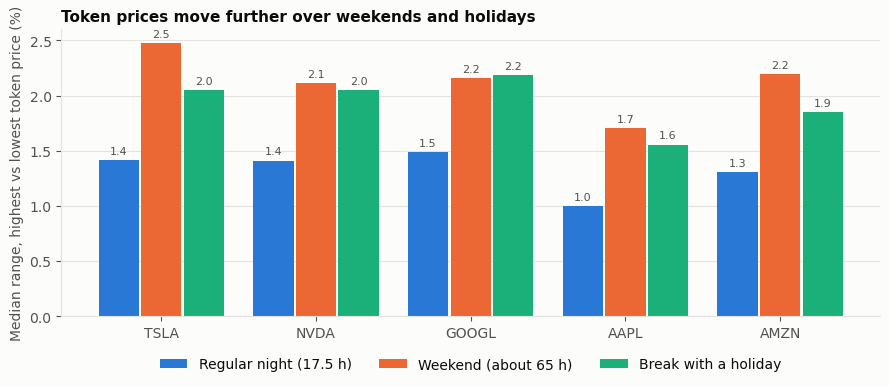

In [17]:
def label_bars(ax, bars, fmt="{:.2f}"):
    for bar in bars:
        ax.annotate(fmt.format(bar.get_height()), (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom",
                    fontsize=8, color=MUTED)

x = np.arange(len(ORDER))
labels = {"overnight": "Regular night (17.5 h)", "weekend": "Weekend (about 65 h)",
          "holiday": "Break with a holiday"}
colors = {"overnight": BLUE, "weekend": ORANGE, "holiday": AQUA}
width = 0.26

fig, ax = plt.subplots(figsize=(9, 4))
for i, column in enumerate(range_by_type.columns):
    bars = ax.bar(x + (i - 1) * (width + 0.015), range_by_type[column], width,
                  color=colors[column], label=labels[column])
    label_bars(ax, bars, "{:.1f}")
ax.set_xticks(x, ORDER); ax.xaxis.grid(False)
ax.set_ylabel("Median range, highest vs lowest token price (%)")
ax.set_title("Token prices move further over weekends and holidays", loc="left")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()
fig.savefig(FIG_DIR / "03_token_range_by_night_type.png", dpi=160, bbox_inches="tight")
plt.show()

In a regular night the token price moves within a range of 1.0 % to 1.5 %. Over a weekend the range grows to 1.7 % to 2.5 %, and breaks with a public holiday are on a similar level. The longer the exchange is closed, the further the token moves, but not in proportion: a weekend is almost four times as long as a night, while the range is less than twice as wide.

## 14. Question 3: Does the Token Predict the Opening Price?

If the token market processes news while Nasdaq is closed, the token's move during the closed period should match the stock's gap from close to open. Three measures:

- **Correlation** between the token move and the stock gap.
- **Forecast error:** the median absolute distance to the real opening price for two forecasts, the token price before the open and, as a naive benchmark, yesterday's closing price.
- **Direction:** the share of closed periods in which token and stock moved in the same direction, counted only where the stock gap was at least 0.5 %.

In [18]:
def prediction_quality(g):
    g = g.dropna(subset=["token_move_pct", "stock_gap_pct"])
    real_gap = g[g["stock_gap_pct"].abs() >= 0.5]
    naive_error = 100 * (g["stock_close"] / g["stock_open"] - 1)  # distance to the real open, like pre_open_error_pct
    return pd.Series({
        "nights": len(g),
        "correlation": g["token_move_pct"].corr(g["stock_gap_pct"]),
        "naive_error": naive_error.abs().median(),               # forecast: open = yesterday's close
        "token_error": g["pre_open_error_pct"].abs().median(),   # forecast: open = token before the open
        "same_direction_pct": 100 * (np.sign(real_gap["token_move_pct"])
                                     == np.sign(real_gap["stock_gap_pct"])).mean(),
    })

q3_by_ticker = nights.groupby("ticker").apply(prediction_quality, include_groups=False).reindex(ORDER)
q3_by_type = nights.groupby("night_type").apply(prediction_quality, include_groups=False)

print("By stock")
display(q3_by_ticker.round(3))
print("By type of closed period")
display(q3_by_type.round(3))

By stock


,nights,correlation,naive_error,token_error,same_direction_pct
ticker,,,,,
TSLA,310.0,0.952,0.846,0.217,97.696
NVDA,310.0,0.961,0.829,0.178,99.020
GOOGL,310.0,0.948,0.528,0.249,97.531
AAPL,309.0,0.880,0.323,0.266,95.575
AMZN,310.0,0.907,0.530,0.301,94.578


By type of closed period


,nights,correlation,naive_error,token_error,same_direction_pct
night_type,,,,,
holiday,55.0,0.930,0.871,0.257,100.000
overnight,1214.0,0.946,0.544,0.234,96.899
weekend,280.0,0.878,0.717,0.237,97.191


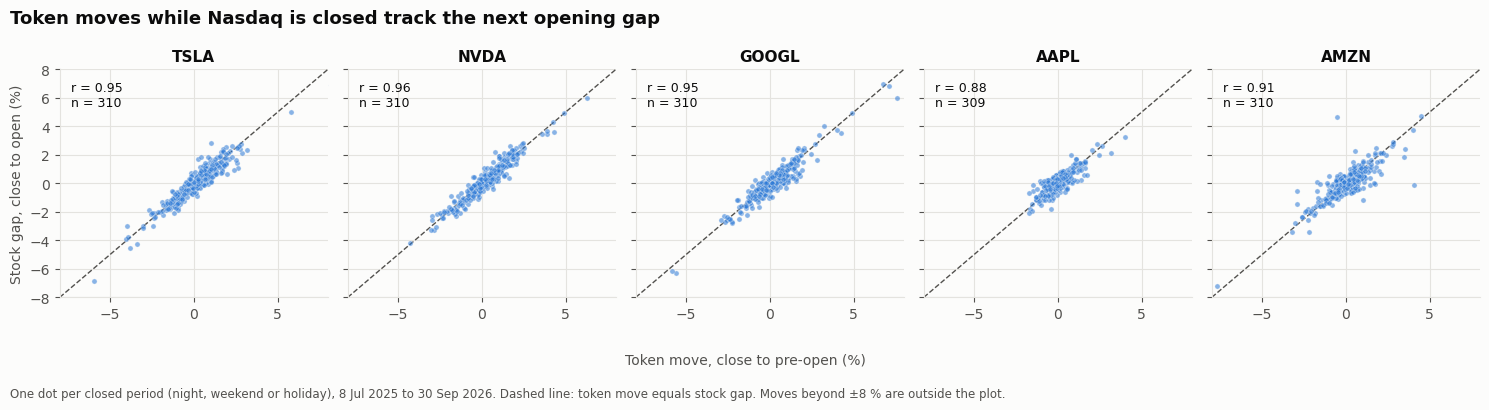

In [19]:
LIMIT = 8
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharex=True, sharey=True)
for ax, ticker in zip(axes, ORDER):
    g = nights[nights["ticker"] == ticker].dropna(subset=["token_move_pct", "stock_gap_pct"])
    ax.plot([-LIMIT, LIMIT], [-LIMIT, LIMIT], color=MUTED, linewidth=1, linestyle="--", zorder=1)
    ax.scatter(g["token_move_pct"], g["stock_gap_pct"], s=14, color=BLUE, alpha=0.55,
               edgecolor=SURFACE, linewidth=0.4, zorder=2)
    ax.set_title(ticker)
    ax.text(0.04, 0.95, f"r = {g['token_move_pct'].corr(g['stock_gap_pct']):.2f}\nn = {len(g)}",
            transform=ax.transAxes, va="top", fontsize=9, color=INK)
    ax.set_xlim(-LIMIT, LIMIT); ax.set_ylim(-LIMIT, LIMIT)
axes[0].set_ylabel("Stock gap, close to open (%)")
fig.suptitle("Token moves while Nasdaq is closed track the next opening gap",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.supxlabel("Token move, close to pre-open (%)", y=0.085, fontsize=10, color=MUTED)
fig.text(0.01, 0.01, "One dot per closed period (night, weekend or holiday), 8 Jul 2025 to 30 Sep 2026. "
         "Dashed line: token move equals stock gap. Moves beyond ±8 % are outside the plot.",
         fontsize=8.5, color=MUTED)
fig.tight_layout(rect=[0, 0.09, 1, 1])
fig.savefig(FIG_DIR / "01_token_move_vs_stock_gap.png", dpi=160)
plt.show()

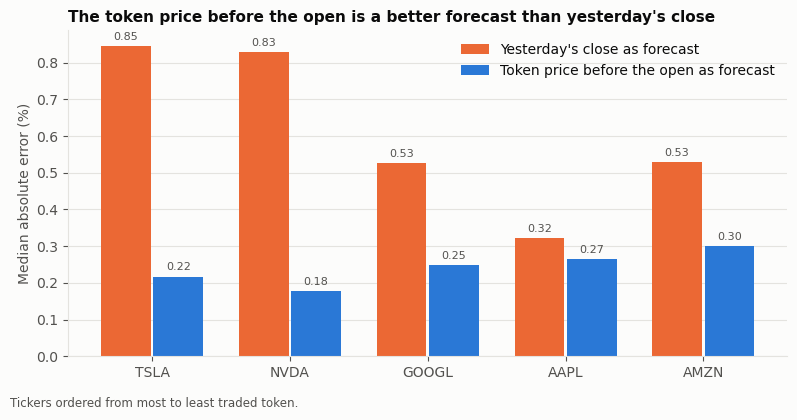

In [20]:
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
bars_naive = ax.bar(x - width / 2 - 0.01, q3_by_ticker["naive_error"], width, color=ORANGE,
                    label="Yesterday's close as forecast")
bars_token = ax.bar(x + width / 2 + 0.01, q3_by_ticker["token_error"], width, color=BLUE,
                    label="Token price before the open as forecast")
label_bars(ax, bars_naive); label_bars(ax, bars_token)
ax.set_xticks(x, ORDER); ax.xaxis.grid(False)
ax.set_ylabel("Median absolute error (%)")
ax.set_title("The token price before the open is a better forecast than yesterday's close", loc="left")
ax.legend(frameon=False, loc="upper right")
fig.text(0.01, -0.03, "Tickers ordered from most to least traded token.", fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_opening_price_forecast_error.png", dpi=160, bbox_inches="tight")
plt.show()

The token move during the closed period is strongly correlated with the stock's opening gap (0.88 to 0.96), and where the stock gapped by at least 0.5 %, the token had moved in the same direction in 95 % to 99 % of the cases.

The token price before the open misses the real opening price by a median of 0.18 % to 0.30 %. For Tesla and Nvidia this is about a quarter of the naive benchmark's error. For Apple the advantage is small (0.27 % against 0.32 %), because Apple's overnight gaps were small in this period and left little to predict. The relationship is weaker over weekends (correlation 0.88) than over regular nights (0.95).

## 15. Question 4: Buying at the Close, Selling After the Open

A simple test of whether the closed period can be traded: buy the token in the last half-hour before the close and sell it in the first half-hour after the next open, in every closed period. Dune does not provide pool fees for these tokens (the `fee_tier` column is empty for Raydium and most other venues), so costs enter as round-trip scenarios of 0.1 % to 1.0 %. The mean gross return is at the same time the break-even cost.

In [21]:
def trade_result(g):
    returns = g["trade_pct"].dropna()
    result = {"trades": len(returns), "mean_gross": returns.mean(), "median_gross": returns.median(),
              "win_rate_pct": 100 * (returns > 0).mean(),
              "stock_close_to_open": g["stock_gap_pct"].mean()}
    for cost in COSTS:
        result[f"net_at_{cost}"] = returns.mean() - cost
    return pd.Series(result)

q4 = nights.groupby("ticker").apply(trade_result, include_groups=False).reindex(ORDER)
q4.round(3)

,trades,mean_gross,median_gross,win_rate_pct,stock_close_to_open,net_at_0.1,net_at_0.3,net_at_0.5,net_at_1.0
ticker,,,,,,,,,
TSLA,310.0,0.067,0.171,54.839,0.054,-0.033,-0.233,-0.433,-0.933
NVDA,310.0,0.184,0.216,57.097,0.209,0.084,-0.116,-0.316,-0.816
GOOGL,310.0,0.148,0.089,52.903,0.081,0.048,-0.152,-0.352,-0.852
AAPL,309.0,0.075,0.110,54.693,0.065,-0.025,-0.225,-0.425,-0.925
AMZN,308.0,0.062,0.028,50.974,0.105,-0.038,-0.238,-0.438,-0.938


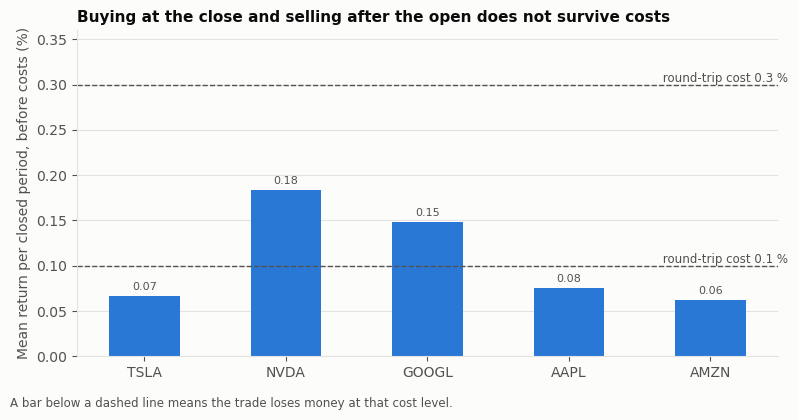

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(x, q4["mean_gross"], 0.5, color=BLUE)
label_bars(ax, bars)
for cost in [0.1, 0.3]:
    ax.axhline(cost, color=MUTED, linewidth=1, linestyle="--")
    ax.text(len(ORDER) - 0.45, cost, f" round-trip cost {cost} %", va="bottom", ha="right",
            fontsize=8.5, color=MUTED)
ax.set_ylim(0, 0.36)
ax.set_xticks(x, ORDER); ax.xaxis.grid(False)
ax.set_ylabel("Mean return per closed period, before costs (%)")
ax.set_title("Buying at the close and selling after the open does not survive costs", loc="left")
fig.text(0.01, -0.03, "A bar below a dashed line means the trade loses money at that cost level.",
         fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_overnight_trade_return_vs_costs.png", dpi=160, bbox_inches="tight")
plt.show()

The trade earns a mean of 0.06 % to 0.18 % per closed period before costs. At a round-trip cost of 0.3 % all five tokens lose money, and at 0.1 % only Nvidia and Alphabet stay positive.

The small gross return is not a token effect. The stocks themselves rose by a similar amount from close to open in this period (column `stock_close_to_open`), so the trade simply collects the general overnight drift of a rising market.

## 16. Question 5: Liquid vs. Thin Tokens

The five tokens differ strongly in trading activity. The table compares, per token, the median traded volume per closed period with three quality measures: the share of half-hours with a price, the spread of the basis at the close, and the forecast error before the open.

In [23]:
q5 = nights.groupby("ticker").agg(
    volume_per_night_usd=("token_volume_usd", "median"),
    coverage_pct=("coverage_pct", "mean"),
    basis_std=("basis_at_close_pct", "std"),
    pre_open_error=("pre_open_error_pct", lambda s: s.abs().median()),
    token_range=("token_range_pct", "median")).reindex(ORDER)
q5.round(3)

,volume_per_night_usd,coverage_pct,basis_std,pre_open_error,token_range
ticker,,,,,
TSLA,645522.189,99.974,0.322,0.217,1.626
NVDA,394637.654,99.956,0.296,0.178,1.571
GOOGL,92352.550,97.246,0.305,0.249,1.581
AAPL,28840.687,94.492,0.299,0.265,1.068
AMZN,25960.105,86.493,0.494,0.301,1.500


Tracking quality falls with liquidity. Tesla and Nvidia trade several hundred thousand USD per closed period, have a price in practically every half-hour and the smallest forecast errors. Apple and Amazon trade below 30,000 USD per closed period; the Amazon token has no price in 13.5 % of the half-hours of an average closed period, the widest basis and the largest forecast error.

A thin token does deviate more from the stock, but Section 15 shows that this does not turn into a profitable trade: the deviations are smaller than realistic trading costs.

## 17. Question 6: The Price Path Within a Night

Sections 13 and 14 look at each closed period as a whole. This section follows the token price through the night, half-hour by half-hour, and asks when the adjustment to the next opening price happens.

Only regular nights are used (17.5 hours from the 16:00 close to the 9:30 open), so every night has the same clock. For every half-hour the chart shows the median distance between the token price and the stock's next opening price. The lower panel shows when the tokens are traded during the night.

In [24]:
SERIES_COLORS = dict(zip(ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

regular = nights[(nights["night_type"] == "overnight") & (nights["hours_closed"] == 17.5)]
path = tokens[tokens["night_type"] == "overnight"].merge(
    regular[["ticker", "prev_trading_day", "close_utc", "stock_open"]], on=["ticker", "prev_trading_day"])
path["hours_since_close"] = (path["time_utc"] - path["close_utc"]).dt.total_seconds() / 3600
path["distance_pct"] = 100 * (path["price_usd"] / path["stock_open"] - 1).abs()

distance = path.pivot_table(index="hours_since_close", columns="ticker", values="distance_pct",
                            aggfunc="median")[ORDER]
volume_share = 100 * path.groupby("hours_since_close")["volume_usd"].sum() / path["volume_usd"].sum()
night_phase = pd.cut(volume_share.index, [-0.1, 3.9, 11.9, 17.6],
                     labels=["post_market (16:00-20:00)", "closed (20:00-04:00)", "pre_market (04:00-09:30)"])

print("Regular nights per stock:", regular.groupby("ticker").size().iloc[0])
print("Median distance to the next opening price (%), by hours since the close")
display(distance.loc[[0.0, 4.0, 8.0, 12.0, 17.0]].round(2))
print("Share of night volume by phase (%)")
display(volume_share.groupby(night_phase, observed=True).sum().round(1).to_frame("volume_share_pct"))

Regular nights per stock: 243
Median distance to the next opening price (%), by hours since the close


ticker,TSLA,NVDA,GOOGL,AAPL,AMZN
hours_since_close,,,,,
0.0,0.71,0.71,0.62,0.39,0.57
4.0,0.63,0.63,0.56,0.35,0.57
8.0,0.60,0.52,0.64,0.42,0.59
12.0,0.51,0.52,0.52,0.35,0.57
17.0,0.22,0.18,0.25,0.26,0.28


Share of night volume by phase (%)


,volume_share_pct
post_market (16:00-20:00),26.6
closed (20:00-04:00),36.2
pre_market (04:00-09:30),37.3


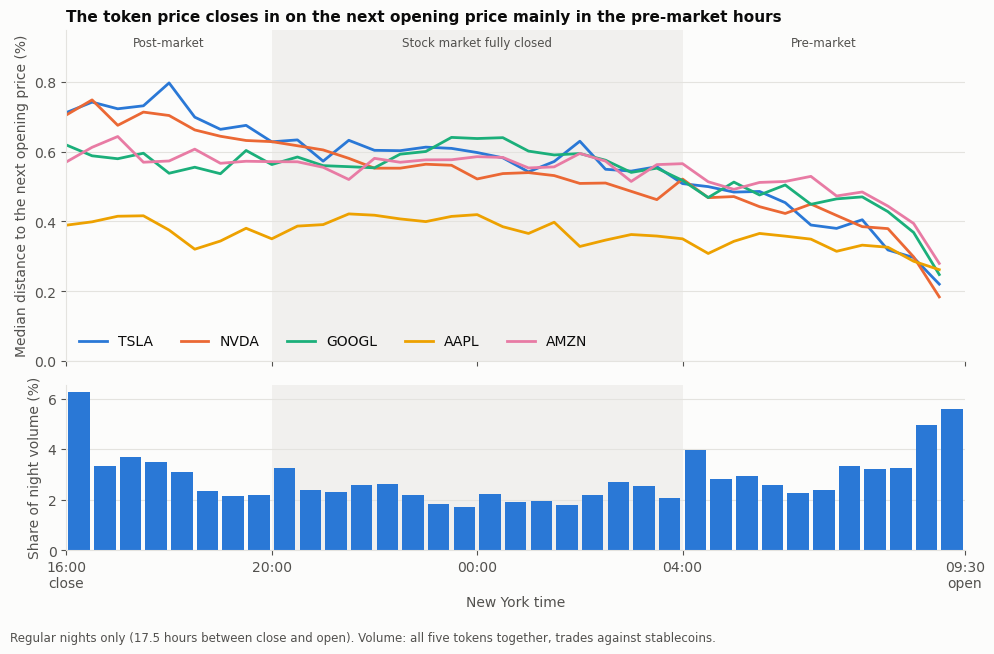

In [25]:
PHASES = [(0, 4, "Post-market"), (4, 12, "Stock market fully closed"), (12, 17.5, "Pre-market")]
TICKS = [0, 4, 8, 12, 17.5]
TICK_LABELS = ["16:00\nclose", "20:00", "00:00", "04:00", "09:30\nopen"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for ax in (ax1, ax2):
    ax.axvspan(4, 12, color=GRID, alpha=0.45, linewidth=0, zorder=0)
    ax.xaxis.grid(False)
for ticker in ORDER:
    ax1.plot(distance.index, distance[ticker], color=SERIES_COLORS[ticker], linewidth=2, label=ticker)
for start, end, name in PHASES:
    ax1.text((start + end) / 2, 0.98, name, transform=ax1.get_xaxis_transform(), ha="center",
             va="top", fontsize=8.5, color=MUTED)
ax1.set_ylim(0, 0.95)
ax1.set_ylabel("Median distance to the next opening price (%)")
ax1.set_title("The token price closes in on the next opening price mainly in the pre-market hours",
              loc="left")
ax1.legend(frameon=False, ncol=5, loc="lower left")

ax2.bar(volume_share.index + 0.25, volume_share, 0.42, color=BLUE)
ax2.set_ylabel("Share of night volume (%)")
ax2.set_xticks(TICKS, TICK_LABELS)
ax2.set_xlim(0, 17.5)
ax2.set_xlabel("New York time")
fig.text(0.01, 0.005, "Regular nights only (17.5 hours between close and open). "
         "Volume: all five tokens together, trades against stablecoins.", fontsize=8.5, color=MUTED)
fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(FIG_DIR / "05_night_path_to_open.png", dpi=160)
plt.show()

The adjustment is not spread evenly over the night. For Tesla and Nvidia the distance to the next opening price falls slowly from about 0.7 % at the close to about 0.5 % at 04:00, and then drops to about 0.2 % during the pre-market hours. Most of the information that moves the opening price reaches the token only once pre-market trading in the stock has started. Apple stays almost flat until the last two hours, because its overnight gaps were small.

Token trading never stops during the night. About 36 % of the night volume is traded between 20:00 and 04:00, when no stock market session is open, and the busiest half-hours are the first after the close and the last before the open.

## 18. Question 7: Token vs. Stock Before and After Hours

The stock itself also trades outside the regular session, in the pre-market (4:00 to 9:30) and the post-market (16:00 to 20:00). This section compares the token with these prices in two ways:

- **Deviation by session:** the same measure as in Section 12, now for all three sessions. Every token half-hour is assigned to the stock bar that contains it. Bars flagged as spikes are left out.
- **Post-market move:** the stock's move from the official close to its last post-market bar, compared with the token's move over the same window. This shows whether the token follows news that arrives right after the close, such as earnings.

The pre-market and post-market prices come from Yahoo Finance and are less reliable than the regular session (see Section 7), so these results are indicative.

In [26]:
SESSIONS = ["pre_market", "market_hours", "post_market"]

bars_all = (stocks_hourly[~stocks_hourly["is_spike"]]
            .assign(stock=lambda d: (d["open"] + d["close"]) / 2, bar_utc=lambda d: d["time_utc"])
            .sort_values("time_utc"))

# The 09:00 bar (pre-market) and the 15:30 bar (last regular bar) last 30 minutes, all other bars 60 minutes
bar_minutes = np.where(bars_all["time_ny"].dt.strftime("%H:%M").isin(["09:00", "15:30"]), 30, 60)
bars_all["bar_end"] = bars_all["time_utc"] + pd.to_timedelta(bar_minutes, unit="min")

# Assign every token half-hour to the stock bar that contains it
slots = tokens.dropna(subset=["price_usd"]).sort_values("time_utc")
slots = pd.merge_asof(slots[["ticker", "time_utc", "price_usd"]], bars_all[["ticker", "time_utc", "bar_utc", "bar_end"]],
                      on="time_utc", by="ticker", direction="backward", tolerance=pd.Timedelta("59min"))
slots = slots[slots["time_utc"] < slots["bar_end"]]          # a bar that has already ended does not contain the half-hour
token_per_bar = (slots.dropna(subset=["bar_utc"]).groupby(["ticker", "bar_utc"])["price_usd"]
                      .mean().rename("token").reset_index())
q7 = bars_all.merge(token_per_bar, on=["ticker", "bar_utc"])
q7["abs_deviation_pct"] = 100 * (q7["token"] / q7["stock"] - 1).abs()

deviation_by_session = q7.pivot_table(index="ticker", columns="session", values="abs_deviation_pct",
                                      aggfunc="mean").reindex(ORDER)[SESSIONS]
print("Bars compared:", q7.groupby("session").size().reindex(SESSIONS).to_dict())
print("Mean absolute deviation, token vs stock (%)")
deviation_by_session.round(3)

Bars compared: {'pre_market': 9175, 'market_hours': 10809, 'post_market': 5710}
Mean absolute deviation, token vs stock (%)


session,pre_market,market_hours,post_market
ticker,,,
TSLA,0.203,0.192,0.188
NVDA,0.169,0.170,0.148
GOOGL,0.276,0.242,0.289
AAPL,0.279,0.246,0.290
AMZN,0.339,0.294,0.355


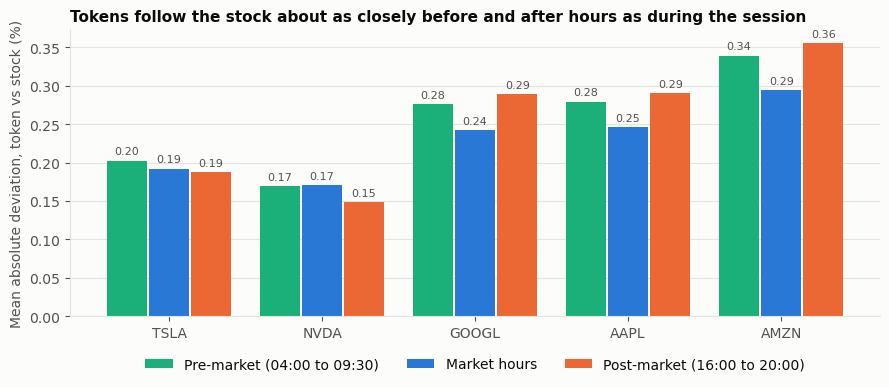

In [27]:
labels = {"pre_market": "Pre-market (04:00 to 09:30)", "market_hours": "Market hours",
          "post_market": "Post-market (16:00 to 20:00)"}
colors = {"pre_market": AQUA, "market_hours": BLUE, "post_market": ORANGE}
width = 0.26

fig, ax = plt.subplots(figsize=(9, 4))
for i, column in enumerate(SESSIONS):
    bars = ax.bar(x + (i - 1) * (width + 0.015), deviation_by_session[column], width,
                  color=colors[column], label=labels[column])
    label_bars(ax, bars)
ax.set_xticks(x, ORDER); ax.xaxis.grid(False)
ax.set_ylabel("Mean absolute deviation, token vs stock (%)")
ax.set_title("Tokens follow the stock about as closely before and after hours as during the session",
             loc="left")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()
fig.savefig(FIG_DIR / "06_deviation_by_session.png", dpi=160, bbox_inches="tight")
plt.show()

In [28]:
post = stocks_hourly[(stocks_hourly["session"] == "post_market") & ~stocks_hourly["is_spike"]].copy()
post["prev_trading_day"] = post["time_utc"].dt.tz_convert(NY).dt.date
last_post = post.sort_values("time_utc").groupby(["ticker", "prev_trading_day"]).tail(1)
last_post = last_post.assign(end_utc=last_post["time_utc"] + pd.Timedelta("1h"))
last_post = last_post.rename(columns={"close": "stock_post"})[["ticker", "prev_trading_day", "stock_post", "end_utc"]]

evenings = nights.merge(last_post, on=["ticker", "prev_trading_day"])
key_post = pd.MultiIndex.from_arrays([evenings["ticker"], evenings["end_utc"] - pd.Timedelta("30min")])
evenings["token_post"] = price_filled.reindex(key_post).to_numpy()
evenings["stock_post_move_pct"] = 100 * (evenings["stock_post"] / evenings["stock_close"] - 1)
evenings["token_post_move_pct"] = 100 * (evenings["token_post"] / evenings["token_close"] - 1)

def post_market_quality(g):
    g = g.dropna(subset=["stock_post_move_pct", "token_post_move_pct"])
    large = g[g["stock_post_move_pct"].abs() >= 1]
    return pd.Series({
        "evenings": len(g),
        "correlation": g["stock_post_move_pct"].corr(g["token_post_move_pct"]),
        "median_abs_stock_move": g["stock_post_move_pct"].abs().median(),
        "evenings_with_move_over_1pct": len(large),
        "same_direction_pct": 100 * (np.sign(large["stock_post_move_pct"])
                                     == np.sign(large["token_post_move_pct"])).mean(),
    })

evenings.groupby("ticker").apply(post_market_quality, include_groups=False).reindex(ORDER).round(3)

,evenings,correlation,median_abs_stock_move,evenings_with_move_over_1pct,same_direction_pct
ticker,,,,,
TSLA,310.0,0.826,0.215,15.0,93.333
NVDA,310.0,0.880,0.247,18.0,94.444
GOOGL,310.0,0.862,0.207,15.0,100.000
AAPL,308.0,0.848,0.151,8.0,100.000
AMZN,308.0,0.900,0.148,12.0,100.000


The tokens follow the stock's pre-market and post-market prices about as closely as they follow it during the regular session. For Tesla and Nvidia the deviation is practically the same in all three sessions (0.15 % to 0.20 %). For the three thinner tokens it is somewhat higher outside the session, by up to 0.06 percentage points.

The token also follows news after the close. The token's move between the close and the end of the post-market is correlated with the stock's post-market move at 0.83 to 0.90. On the evenings when the stock moved by at least 1 % after the close (8 to 18 evenings per stock), the token moved in the same direction in 93 % to 100 % of the cases.

## 19. Limitations

The analysis covers 15 months and 310 closed periods per stock, of which only 56 are weekends and 11 include a public holiday. Results for weekends and holidays rest on few observations and can be shaped by single events.

Token prices are 30-minute volume-weighted averages of DEX trades against USD stablecoins. Trades on centralized exchanges are not included, and an average over 30 minutes is not a price at which a trade could have been executed at a given moment. The trade in Section 15 is therefore an approximation.

Trading costs are scenarios, not measurements. Dune does not provide pool fees for these tokens, and slippage in thin pools is not modelled. Real costs for the thin tokens are likely to be higher than for the liquid ones.

Stock prices outside market hours come from Yahoo Finance and contain bad ticks and missing bars. They are flagged and used only in Section 18; all other results rely on official opening and closing prices. On the two shortened trading days in the window the closing price is approximated (Section 8).

Dividends are not adjusted. Apple, Alphabet and Nvidia paid five dividends each in the period, between 0.01 and 0.27 USD per share, which slightly distorts the stock gap on the ex-dividend dates.

The token market changed during the period: trading volume grew strongly in 2026, and in September 2026 a large share of trades ran against other tokens instead of stablecoins. Results are averages over a market that was still developing.

The selection threshold of 5,000 trades per month and the exclusion of crypto-related companies are choices. A different threshold would add or remove tokens.

## 20. Summary and Key Findings

- **The tokens track the stocks closely while Nasdaq is open.** The mean absolute deviation is **0.17 %** (Nvidia) to **0.29 %** (Amazon), with a small premium of the token in all five cases.
- **The token market keeps moving while Nasdaq is closed**, which is **81 %** of the time. The median price range is **1.0 % to 1.5 %** in a regular night and **1.7 % to 2.5 %** over a weekend.
- **The token price anticipates the opening price.** The correlation between the token move during the closed period and the stock's opening gap is **0.88 to 0.96**, and the direction matched in **95 % to 99 %** of the closed periods with a gap of at least 0.5 %.
- **The forecast is good, not perfect.** The token price before the open misses the real opening price by a median of **0.18 % to 0.30 %**. This beats yesterday's close clearly for Tesla and Nvidia (**0.85 %** and **0.83 %**), but only slightly for Apple (**0.27 %** against **0.32 %**).
- **There is no profitable simple trade.** Buying at the close and selling after the open earns **0.06 % to 0.18 %** per closed period before costs, about as much as the stocks themselves gained overnight. At a round-trip cost of **0.3 %** all five tokens lose money.
- **Liquidity matters.** The thinly traded Amazon token has no price in **13.5 %** of the half-hours of an average closed period and the largest forecast error (**0.30 %**); the heavily traded Nvidia token has the smallest (**0.18 %**).
- **The adjustment happens late in the night.** In a regular night the median distance to the next opening price falls from about **0.7 %** at the close to about **0.5 %** at 04:00 for Tesla and Nvidia, and to about **0.2 %** during the pre-market hours. About **36 %** of the night volume is traded between 20:00 and 04:00, when no stock market session is open.
- **The tokens also follow the stock before and after hours.** The deviation from the stock's pre-market and post-market prices is close to the deviation during the session, and the token's move after the close is correlated with the stock's post-market move at **0.83 to 0.90**.
- **The five tokens follow from a rule, not from taste:** only ten xStocks tokens had at least 5,000 trades in every month, and five of them are well-known single companies without a crypto link.